In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from scipy.stats.mstats import winsorize

In [3]:
np.random.seed(42)

feat_1 = np.random.normal(loc = 60, scale = 6, size = 200)
feat_2 = np.random.exponential(scale = 60, size = 200)
f = np.random.normal(loc=15, scale=3, size=195)
feat_3 = np.append(f, [f.max() + 50, f.max() + 100, f.max() + 150, f.max() + 200, f.max() + 200])

In [5]:
df = pd.DataFrame(
    {
        "Normal": feat_1,
        "Skewed": feat_2,
        "with_outlier": feat_3
    }
)
df.head()

,Normal,Skewed,with_outlier
0,62.980285,125.916518,14.673720
1,59.170414,81.002055,16.205135
2,63.886131,71.644466,17.070432
3,69.138179,72.737253,13.796339
4,58.595080,26.729541,15.672277


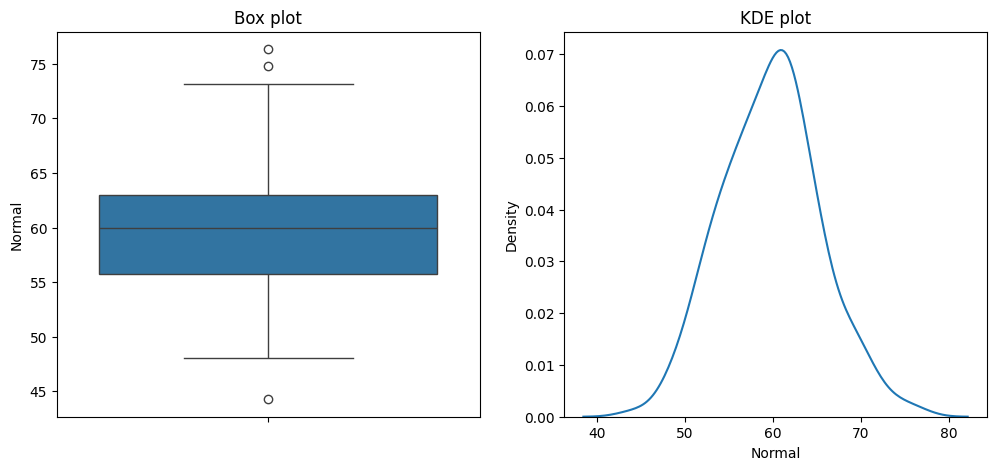

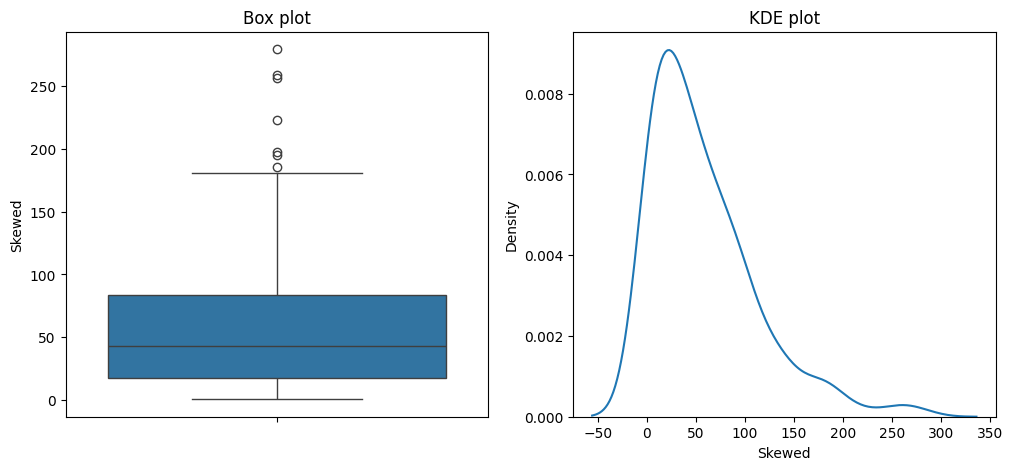

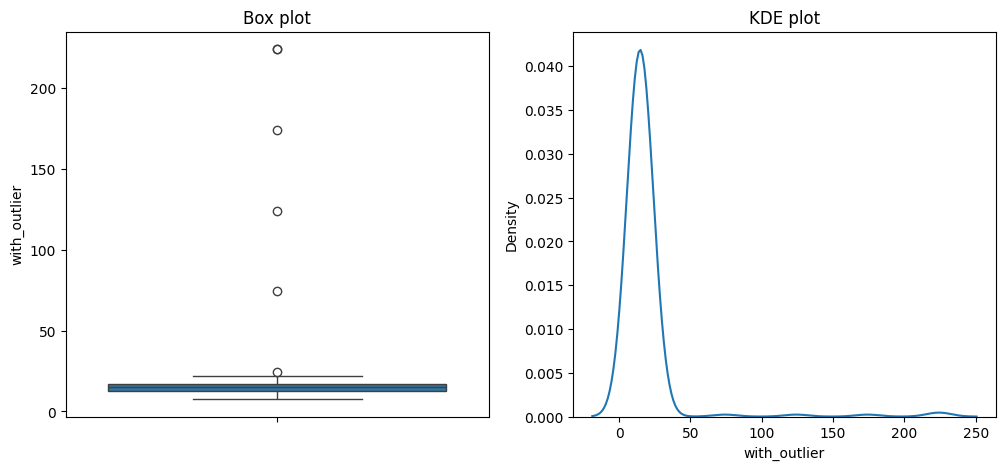

In [6]:
for col in df.columns:
    fig, axes = plt.subplots(1, 2, figsize = (12,5))
    sns.boxplot(df[col], ax = axes[0]).set_title("Box plot")
    sns.kdeplot(df[col], ax = axes[1]).set_title("KDE plot")

In [22]:
minmax_scaler = MinMaxScaler()
standard_scaler = StandardScaler()
robust_scaler = RobustScaler()

minmax_scal = minmax_scaler.fit_transform(df)
standard_scal = standard_scaler.fit_transform(df)
robust_scal = robust_scaler.fit_transform(df)

In [14]:
df_minmax = pd.DataFrame(minmax_scal,columns=df.columns)
df_standard = pd.DataFrame(standard_scal, columns=df.columns)
df_robust = pd.DataFrame(robust_scal, columns=df.columns)

In [15]:
df_minmax.head()

,Normal,Skewed,with_outlier
0,0.583616,0.449346,0.032719
1,0.464704,0.288228,0.039788
2,0.611889,0.254660,0.043782
3,0.775813,0.258580,0.028669
4,0.446747,0.093540,0.037328


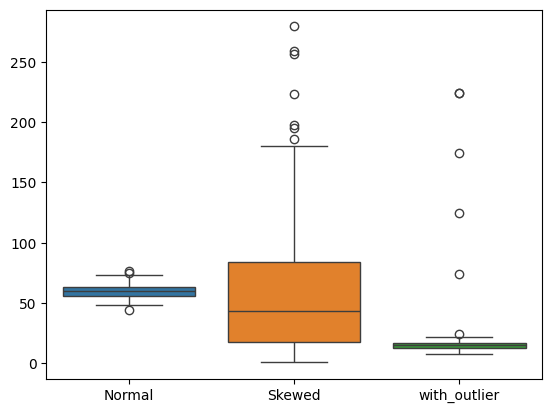

In [20]:
sns.boxplot(df);

<Axes: >

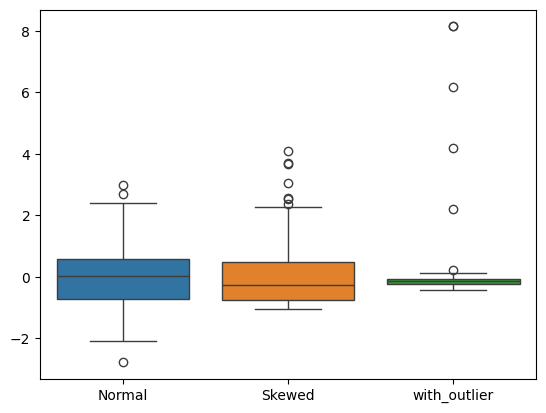

In [18]:
sns.boxplot(df_standard)

<Axes: >

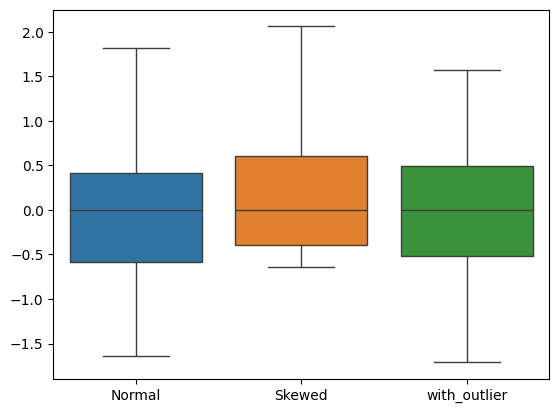

In [23]:
sns.boxplot(df_robust, showfliers = False)

In [33]:
df_bounding = df.copy()
df_bounding['without_outlier'] = np.clip(df['with_outlier'], 0, 200)

<Axes: ylabel='with_outlier'>

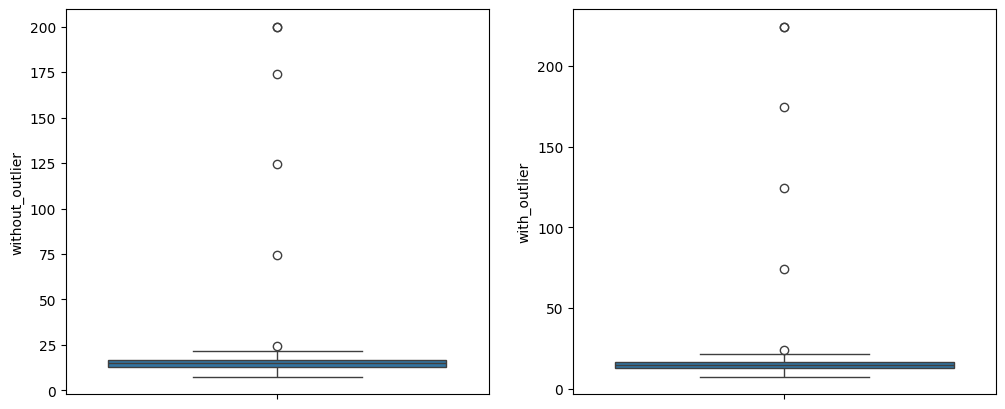

In [35]:
fig, axes = plt.subplots(1,2,figsize = (12,5))
sns.boxplot(df_bounding['without_outlier'], ax = axes[0])
sns.boxplot(df_bounding['with_outlier'], ax = axes[1])

In [39]:
df_winsorize = df.copy()
df_winsorize['without_outlier'] = winsorize(df['with_outlier'], limits=[0.05, 0.05])

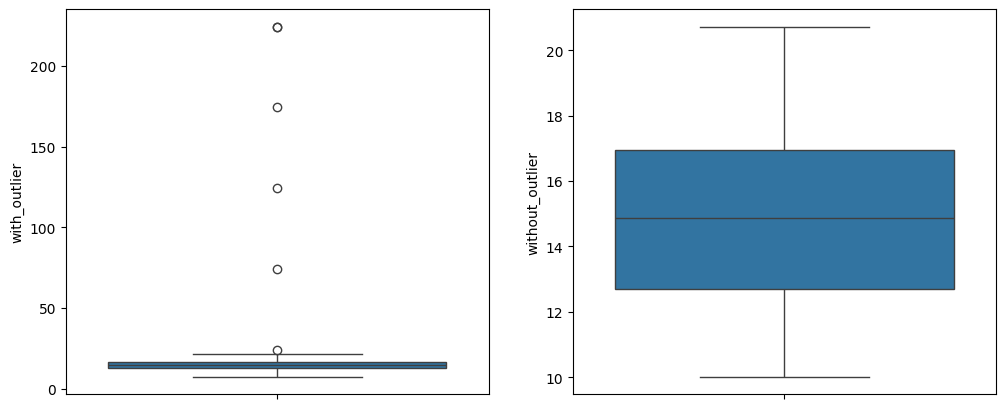

In [42]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1); sns.boxplot(df['with_outlier'])
plt.subplot(1, 2, 2); sns.boxplot(df_winsorize['without_outlier'])
plt.show()